## Exercise 2 - Multiple Linear Regression using SciKit learn 
In Exercise 1 we have predicted "disease_score" here we are trying to predict "disease_score_fluct"

### Step 1 : Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Step 2 : Load Dataset 

In [3]:
df = pd.read_csv("simulated_data_multiple_linear_regression_for_ML.csv")

df.head()

,age,BMI,BP,blood_sugar,Gender,disease_score,disease_score_fluct
0,78,22.862,86.439,90.285,0,890.828,871.203426
1,38,22.413,80.610,90.290,0,789.638,825.044493
2,40,21.752,79.670,86.227,0,772.907,807.954658
3,39,26.339,89.906,84.461,1,808.925,792.264533
4,39,18.539,78.093,89.057,1,771.924,711.895792


### Step 3 : Create x and y 

In [4]:
# Feature Matrix

X = df.drop(columns=["disease_score", "disease_score_fluct"])

# Target Vector

y = df["disease_score_fluct"]

### Step 4 : Split dataset 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step 5 : Create Model 

In [6]:
model = LinearRegression()

### Step 6 : Train Model 

In [7]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1.92, 2.13, 5.27, 3.62,-8.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['age','BMI','BP','blood_sugar','Gender']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-94.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### Step 7 : View Learned equation 

In [8]:
print("Intercept (Bias):")
print(model.intercept_)

print()

print("Coefficients:")
print(model.coef_)

Intercept (Bias):
-94.46426758582368

Coefficients:
[ 1.92465258  2.13308874  5.27482047  3.61658766 -8.53412286]


### Step 8 : Predictions 

In [9]:
y_pred = model.predict(X_test)

### Step 9 : Compare predictions 

In [10]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,871.203426,886.899133
5,882.869178,897.572580
36,803.841641,758.521073
45,738.608159,760.955085
13,845.731275,824.848856
54,836.917389,822.032962
33,781.344099,790.648800
48,1024.474577,861.930436
12,874.950170,808.395168
57,763.566780,751.287648


### Step 10 : Evaluate model 

In [11]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 3236.3344017123018
R² Score: 0.4762358923793565


### Step 11 : Actual v/s Predicted plot 

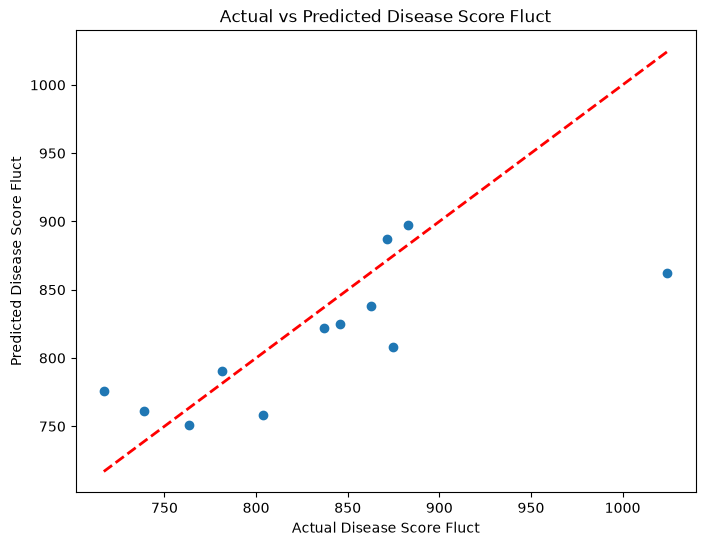

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Disease Score Fluct")

plt.ylabel("Predicted Disease Score Fluct")

plt.title("Actual vs Predicted Disease Score Fluct")

plt.show()

### Step 12 : Residual plot 

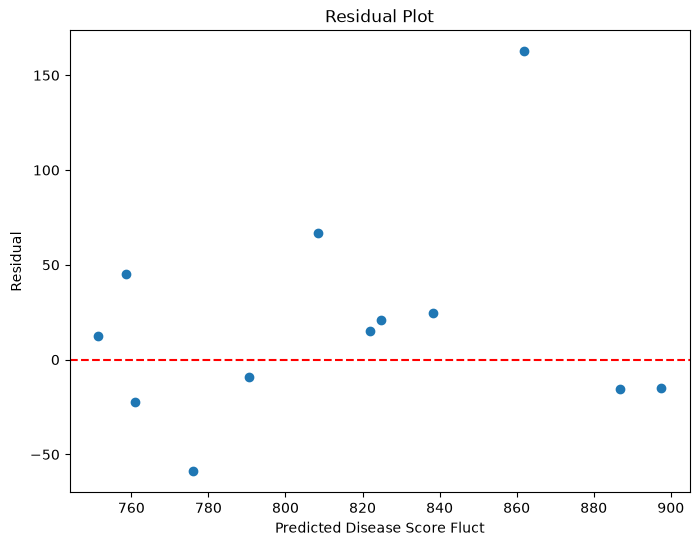

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Disease Score Fluct")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()